# EDA on `Full_Document_Text` — Armenian Legal Documents

Adapted from the original EDA notebook. All steps target the `Full_Document_Text` column.
Armenian-specific notes are included inline.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import nltk
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
from nltk import word_tokenize, sent_tokenize

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

print('All imports done.')

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


All imports done.


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


## 2. Load Data

In [2]:
file_path = '/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/src/data/court_papers_full.csv'  # adjust path if needed
df = pd.read_csv(file_path)

# The target column — note capital T in 'Text'
TEXT_COL = 'Full_Document_Text'

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
display(df.head(3))

Dataset loaded successfully!
Shape: (2073, 4)


,Judge,Category,Case_Number,Verdict_Text
0,Կարեն Մեժլումյան Սուրիկի,1.1 Գույքի նկատմամբ սեփականության իրավունքը ճա...,ԵԴ2/3094/02/24,Պ Ա Ր Զ Ե Ց\n\n(II. Նկարագրական մաս)\n\n1. Գոր...
1,Կարեն Մեժլումյան Սուրիկի,4.9 Երեխայի բնակության վայրը որոշելու վերաբերյալ,ԵԴ2/8206/02/24,Պ Ա Ր Զ Ե Ց\n\nI\n\nՆկարագրական մաս.\n\n1. Գոր...
2,Կարեն Մեժլումյան Սուրիկի,2.1.2 Այդ թվում` գործարքի առոչնչության հետևանք...,ԵԴ2/9445/02/24,Պ Ա Ր Զ Ե Ց\n\n(նկարագրական մաս)\n\n1. \nԳոր...


## 3. Basic Info

In [3]:
df.info()

if TEXT_COL not in df.columns:
    print(f"Column '{TEXT_COL}' not found. Available columns: {list(df.columns)}")
    TEXT_COL = 'Verdict_Text'
    print(f"Using TEXT_COL = '{TEXT_COL}' instead.")

print(f"\nNull values in {TEXT_COL}: {df[TEXT_COL].isnull().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 2073 entries, 0 to 2072
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Judge         2073 non-null   str  
 1   Category      2073 non-null   str  
 2   Case_Number   2073 non-null   str  
 3   Verdict_Text  2073 non-null   str  
dtypes: str(4)
memory usage: 135.8 MB
Column 'Full_Document_Text' not found. Available columns: ['Judge', 'Category', 'Case_Number', 'Verdict_Text']
Using TEXT_COL = 'Verdict_Text' instead.

Null values in Verdict_Text: 0


## 4. Lowercasing

Armenian lowercase works with Python's built-in `.lower()` — no special library needed.

In [4]:
df_lower = df.copy()
df_lower[TEXT_COL] = df_lower[TEXT_COL].apply(
    lambda x: x.lower() if isinstance(x, str) else x
)
df_lower[TEXT_COL] = df_lower[TEXT_COL].astype(str)

print('Lowercasing complete.')
display(df_lower[[TEXT_COL]].head(2))

Lowercasing complete.


,Verdict_Text
0,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...
1,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...


## 5. Tokenization

`re.split('\\W+', text)` splits on any non-word character.  
**Important for Armenian:** Python's `\W` (non-word) does capture Armenian Unicode letters correctly (they fall in `\w`), so basic regex tokenization works.  
For production use, consider `nltk.word_tokenize` with `language='russian'` as a proxy (closest NLTK supports), or a dedicated Armenian tokenizer.

In [5]:
def tokenize(text):
    if not isinstance(text, str):
        text = str(text)
    tokens = re.split(r'\W+', text)
    return [t for t in tokens if t]  # remove empty strings

df_lower[f'Tokenized_{TEXT_COL}'] = df_lower[TEXT_COL].apply(tokenize)

print('Tokenization complete.')
display(df_lower[[TEXT_COL, f'Tokenized_{TEXT_COL}']].head(3))

Tokenization complete.


,Verdict_Text,Tokenized_Verdict_Text
0,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...,"[պ, ա, ր, զ, ե, ց, ii, նկարագրական, մաս, 1, գո..."
1,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...,"[պ, ա, ր, զ, ե, ց, i, նկարագրական, մաս, 1, գոր..."
2,պ ա ր զ ե ց\n\n(նկարագրական մաս)\n\n1. \nգոր...,"[պ, ա, ր, զ, ե, ց, նկարագրական, մաս, 1, գործի,..."


## 6. Stopword Removal

**Armenian note:** NLTK does NOT include Armenian stopwords. We define a small starter set of common Armenian function words. Extend `armenian_stopwords` with domain-specific words for legal texts.

In [6]:
# Starter Armenian stopword list (common function words)
armenian_stopwords = set([
    'և', 'է', 'են', 'էր', 'եղել', 'այն', 'այս', 'դա', 'նա', 'նրա', 'նրանք',
    'որ', 'որը', 'որոնք', 'ով', 'ում', 'կամ', 'բայց', 'եթե', 'երբ', 'ինչ',
    'հետ', 'մեջ', 'վրա', 'մասին', 'համար', 'ըստ', 'կողմից', 'դեմ', 'նախ',
    'կկ', 'ի', 'ու', 'ա', 'ն', 'հ', 'մ', 'վ',  # very short fragments
    'չ', 'ն', 'թ', 'տ', 'ի',
    'հայ', 'հայաստան', 'հՀ', 'հհ',
])

def remove_stopwords_armenian(tokenized_list):
    return [w for w in tokenized_list if w not in armenian_stopwords]

df_lower[f'Stop_{TEXT_COL}'] = df_lower[f'Tokenized_{TEXT_COL}'].apply(remove_stopwords_armenian)

print('Stopword removal complete.')
display(df_lower[[f'Tokenized_{TEXT_COL}', f'Stop_{TEXT_COL}']].head(3))

Stopword removal complete.


,Tokenized_Verdict_Text,Stop_Verdict_Text
0,"[պ, ա, ր, զ, ե, ց, ii, նկարագրական, մաս, 1, գո...","[պ, ր, զ, ե, ց, ii, նկարագրական, մաս, 1, գործի..."
1,"[պ, ա, ր, զ, ե, ց, i, նկարագրական, մաս, 1, գոր...","[պ, ր, զ, ե, ց, i, նկարագրական, մաս, 1, գործի,..."
2,"[պ, ա, ր, զ, ե, ց, նկարագրական, մաս, 1, գործի,...","[պ, ր, զ, ե, ց, նկարագրական, մաս, 1, գործի, դա..."


## 7. Emoji Removal

Same emoji regex as original — works language-agnostically.

In [7]:
def remove_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', str(text))

df_lower[f'Remove_emoji_{TEXT_COL}'] = df_lower[TEXT_COL].apply(remove_emoji)

print('Emoji removal complete.')
display(df_lower[[TEXT_COL, f'Remove_emoji_{TEXT_COL}']].head(2))

Emoji removal complete.


,Verdict_Text,Remove_emoji_Verdict_Text
0,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...
1,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...


## 8. Stemming & Lemmatization

**Armenian note:** NLTK's `SnowballStemmer` and `WordNetLemmatizer` are English-only.  
- Stemming: we apply a simple suffix-stripping regex heuristic for Armenian (removes common inflectional suffixes like -ի, -ից, -ով, -ում, -ների etc.).  
- Lemmatization: true lemmatization requires an Armenian morphological analyzer (e.g., the `hy_core_news_sm` spaCy model). We provide a placeholder and a spaCy version you can enable.

In [8]:
# ── Simple Armenian suffix-stripping stemmer ──────────────────────────────
# Removes common Armenian case/number suffixes. Not exhaustive — treat as
# a lightweight approximation.
ARMENIAN_SUFFIXES = re.compile(
    r'(ներից|ներով|ներում|ների|ների|ներն|ները|'
    r'ից|ով|ում|ի|ն|ը|ն|ւ|ե|ա)$'
)

def stem_armenian(token):
    if len(token) > 3:  # don't strip very short words
        return ARMENIAN_SUFFIXES.sub('', token)
    return token

def stemming_armenian(tokenized_list):
    return [stem_armenian(w) for w in tokenized_list]

df_lower[f'Stem_{TEXT_COL}'] = df_lower[f'Tokenized_{TEXT_COL}'].apply(stemming_armenian)

print('Stemming complete (Armenian heuristic).')
display(df_lower[[f'Tokenized_{TEXT_COL}', f'Stem_{TEXT_COL}']].head(3))

Stemming complete (Armenian heuristic).


,Tokenized_Verdict_Text,Stem_Verdict_Text
0,"[պ, ա, ր, զ, ե, ց, ii, նկարագրական, մաս, 1, գո...","[պ, ա, ր, զ, ե, ց, ii, նկարագրակա, մաս, 1, գոր..."
1,"[պ, ա, ր, զ, ե, ց, i, նկարագրական, մաս, 1, գոր...","[պ, ա, ր, զ, ե, ց, i, նկարագրակա, մաս, 1, գործ..."
2,"[պ, ա, ր, զ, ե, ց, նկարագրական, մաս, 1, գործի,...","[պ, ա, ր, զ, ե, ց, նկարագրակա, մաս, 1, գործ, դ..."


In [9]:
# ── Optional: spaCy lemmatization for Armenian ────────────────────────────
# Requires: pip install spacy && python -m spacy download hy_core_news_sm
# Uncomment the block below to enable proper lemmatization.

# import spacy
# nlp_hy = spacy.load('hy_core_news_sm')
#
# def lemmatize_armenian_spacy(text):
#     doc = nlp_hy(str(text)[:100000])  # spaCy has a text length limit
#     return [token.lemma_ for token in doc]
#
# df_lower[f'Lemma_{TEXT_COL}'] = df_lower[TEXT_COL].apply(lemmatize_armenian_spacy)

# ── Placeholder: same as stem for now ────────────────────────────────────
df_lower[f'Lemma_{TEXT_COL}'] = df_lower[f'Stem_{TEXT_COL}']

print('Lemmatization step done (using stem as proxy; enable spaCy block for true lemmas).')

Lemmatization step done (using stem as proxy; enable spaCy block for true lemmas).


In [10]:
# Whitespace cleaning after emoji removal (same as original)
df_lower[f'Lemmatized_{TEXT_COL}_cleaned'] = df_lower[f'Remove_emoji_{TEXT_COL}'].apply(
    lambda text: re.sub(' +', ' ', str(text)).strip()
)

print('Whitespace cleaning complete.')
display(df_lower[[f'Remove_emoji_{TEXT_COL}', f'Lemmatized_{TEXT_COL}_cleaned']].head(2))

Whitespace cleaning complete.


,Remove_emoji_Verdict_Text,Lemmatized_Verdict_Text_cleaned
0,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...
1,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...


## 9. Feature Engineering — Text Statistics

In [11]:
# ── Sentence count ────────────────────────────────────────────────────────
# NLTK's sent_tokenize defaults to English Punkt model.
# For Armenian, '։' (Armenian full stop, U+0589) is the primary sentence
# delimiter. We add a simple regex split as well.

def split_sentences_armenian(text):
    if not isinstance(text, str):
        text = str(text)
    # Split on Armenian full stop (։), regular period, ! and ?
    sentences = re.split(r'[։\.!?]+', text)
    return [s.strip() for s in sentences if s.strip()]

df_lower[f'{TEXT_COL}_sentence_count'] = df_lower[TEXT_COL].apply(
    lambda x: len(split_sentences_armenian(x))
)

# ── Word count ────────────────────────────────────────────────────────────
df_lower[f'{TEXT_COL}_word_count'] = df_lower[TEXT_COL].apply(
    lambda x: len(x.split())
)

# ── Char count (excluding spaces) ─────────────────────────────────────────
df_lower[f'{TEXT_COL}_char_count'] = df_lower[TEXT_COL].apply(
    lambda x: len(x.replace(' ', ''))
)

print('Sentence, word, char counts calculated.')
display(df_lower[[
    TEXT_COL,
    f'{TEXT_COL}_sentence_count',
    f'{TEXT_COL}_word_count',
    f'{TEXT_COL}_char_count'
]].head(3))

Sentence, word, char counts calculated.


,Verdict_Text,Verdict_Text_sentence_count,Verdict_Text_word_count,Verdict_Text_char_count
0,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...,385,7367,51767
1,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...,167,3149,21919
2,պ ա ր զ ե ց\n\n(նկարագրական մաս)\n\n1. \nգոր...,212,4990,36652


In [12]:
# ── Densities ─────────────────────────────────────────────────────────────
df_lower[f'{TEXT_COL}_word_density'] = (
    df_lower[f'{TEXT_COL}_word_count'] /
    (df_lower[f'{TEXT_COL}_char_count'] + 1)
)
df_lower[f'{TEXT_COL}_sentence_density'] = (
    df_lower[f'{TEXT_COL}_sentence_count'] /
    (df_lower[f'{TEXT_COL}_word_count'] + 1)
)

print('Densities calculated.')
display(df_lower[[
    f'{TEXT_COL}_word_density',
    f'{TEXT_COL}_sentence_density'
]].head(3))

Densities calculated.


,Verdict_Text_word_density,Verdict_Text_sentence_density
0,0.142308,0.052253
1,0.143659,0.053016
2,0.136142,0.042476


In [13]:
# ── Punctuation count ─────────────────────────────────────────────────────
# Extend standard punctuation with Armenian-specific: ։ (full stop), « »
punc = string.punctuation + '։«»'

df_lower[f'{TEXT_COL}_punctuation_count'] = df_lower[TEXT_COL].apply(
    lambda x: len([c for c in x if c in punc])
)

print('Punctuation counts calculated.')
display(df_lower[[TEXT_COL, f'{TEXT_COL}_punctuation_count']].head(3))

Punctuation counts calculated.


,Verdict_Text,Verdict_Text_punctuation_count
0,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...,1894
1,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...,616
2,պ ա ր զ ե ց\n\n(նկարագրական մաս)\n\n1. \nգոր...,978


In [14]:
# ── Stopword count & density ──────────────────────────────────────────────
def count_armenian_stopwords(text):
    tokens = tokenize(text)
    return len([w for w in tokens if w in armenian_stopwords])

df_lower[f'{TEXT_COL}_stopwords_count'] = df_lower[TEXT_COL].apply(count_armenian_stopwords)
df_lower[f'{TEXT_COL}_stopwords_density'] = (
    df_lower[f'{TEXT_COL}_stopwords_count'] /
    (df_lower[f'{TEXT_COL}_word_count'] + 1)
)

print('Stopword counts and densities calculated.')
display(df_lower[[
    TEXT_COL,
    f'{TEXT_COL}_stopwords_count',
    f'{TEXT_COL}_stopwords_density'
]].head(3))

Stopword counts and densities calculated.


,Verdict_Text,Verdict_Text_stopwords_count,Verdict_Text_stopwords_density
0,պ ա ր զ ե ց\n\n(ii. նկարագրական մաս)\n\n1. գոր...,951,0.129072
1,պ ա ր զ ե ց\n\ni\n\nնկարագրական մաս.\n\n1. գոր...,472,0.149841
2,պ ա ր զ ե ց\n\n(նկարագրական մաս)\n\n1. \nգոր...,701,0.140453


## 10. Descriptive Statistics

In [15]:
feature_columns = [
    f'{TEXT_COL}_sentence_count',
    f'{TEXT_COL}_word_count',
    f'{TEXT_COL}_char_count',
    f'{TEXT_COL}_word_density',
    f'{TEXT_COL}_sentence_density',
    f'{TEXT_COL}_punctuation_count',
    f'{TEXT_COL}_stopwords_count',
    f'{TEXT_COL}_stopwords_density',
]

print("Descriptive statistics for Full_Document_Text features:")
display(df_lower[feature_columns].describe())

Descriptive statistics for Full_Document_Text features:


,Verdict_Text_sentence_count,Verdict_Text_word_count,Verdict_Text_char_count,Verdict_Text_word_density,Verdict_Text_sentence_density,Verdict_Text_punctuation_count,Verdict_Text_stopwords_count,Verdict_Text_stopwords_density
count,2073.000000,2073.000000,2073.000000,2073.000000,2073.000000,2073.000000,2073.000000,2073.000000
mean,228.243126,4600.123010,33389.279305,0.137729,0.053074,1052.923782,698.057405,0.147723
std,226.425294,4072.468271,29555.644937,0.005165,0.019405,1006.814098,644.260291,0.017115
min,9.000000,95.000000,856.000000,0.110852,0.017900,25.000000,12.000000,0.092890
25%,80.000000,1552.000000,11289.000000,0.135071,0.039355,351.000000,217.000000,0.136139
50%,167.000000,3410.000000,24985.000000,0.137790,0.049342,756.000000,507.000000,0.148906
75%,303.000000,6228.000000,44658.000000,0.140608,0.063158,1406.000000,908.000000,0.159179
max,2578.000000,30962.000000,235144.000000,0.161122,0.173131,11848.000000,4871.000000,0.203840


## 11. Visualizations — Box Plots & Histograms (Seaborn)

Same helper structure as original, now using `sns.boxplot` / `sns.histplot` for cleaner Armenian-unicode-safe plots.

In [16]:
# ── Helper functions ──────────────────────────────────────────────────────

def plot_box_plots(data, columns, num_rows=2, num_cols=4):
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(22, 5))
    axes = axes.flatten()
    for i, col in enumerate(columns):
        if i < len(axes):
            sns.boxplot(y=data[col], ax=axes[i], color='steelblue')
            short_name = col.replace('Full_Document_Text_', '').replace('_', ' ')
            axes[i].set_title(short_name)
            axes[i].set_xlabel('')
    for i in range(len(columns), len(axes)):
        axes[i].axis('off')
    plt.suptitle('Box Plots — Full_Document_Text Features', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_histograms(data, columns, num_rows=2, num_cols=4):
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(22, 7))
    axes = axes.flatten()
    for i, col in enumerate(columns):
        if i < len(axes):
            sns.histplot(data[col].dropna(), bins=40, ax=axes[i],
                         color='steelblue', kde=True)
            short_name = col.replace('Full_Document_Text_', '').replace('_', ' ')
            axes[i].set_title(short_name)
            axes[i].set_xlabel('Value')
            axes[i].set_ylabel('Frequency')
    for i in range(len(columns), len(axes)):
        axes[i].axis('off')
    plt.suptitle('Histograms — Full_Document_Text Features', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

Box plots for Full_Document_Text features:


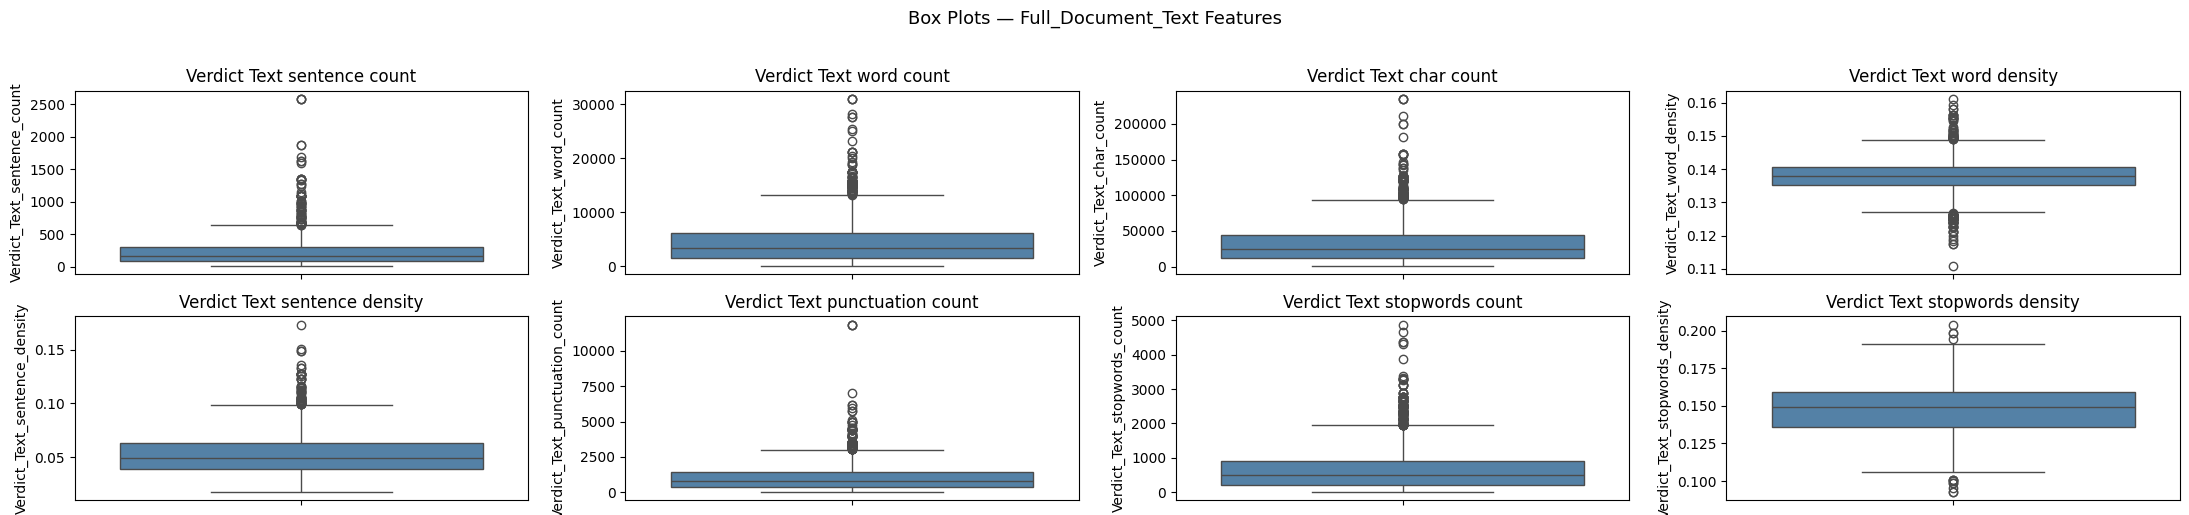

In [17]:
print('Box plots for Full_Document_Text features:')
plot_box_plots(df_lower, feature_columns, num_rows=2, num_cols=4)

Histograms for Full_Document_Text features:


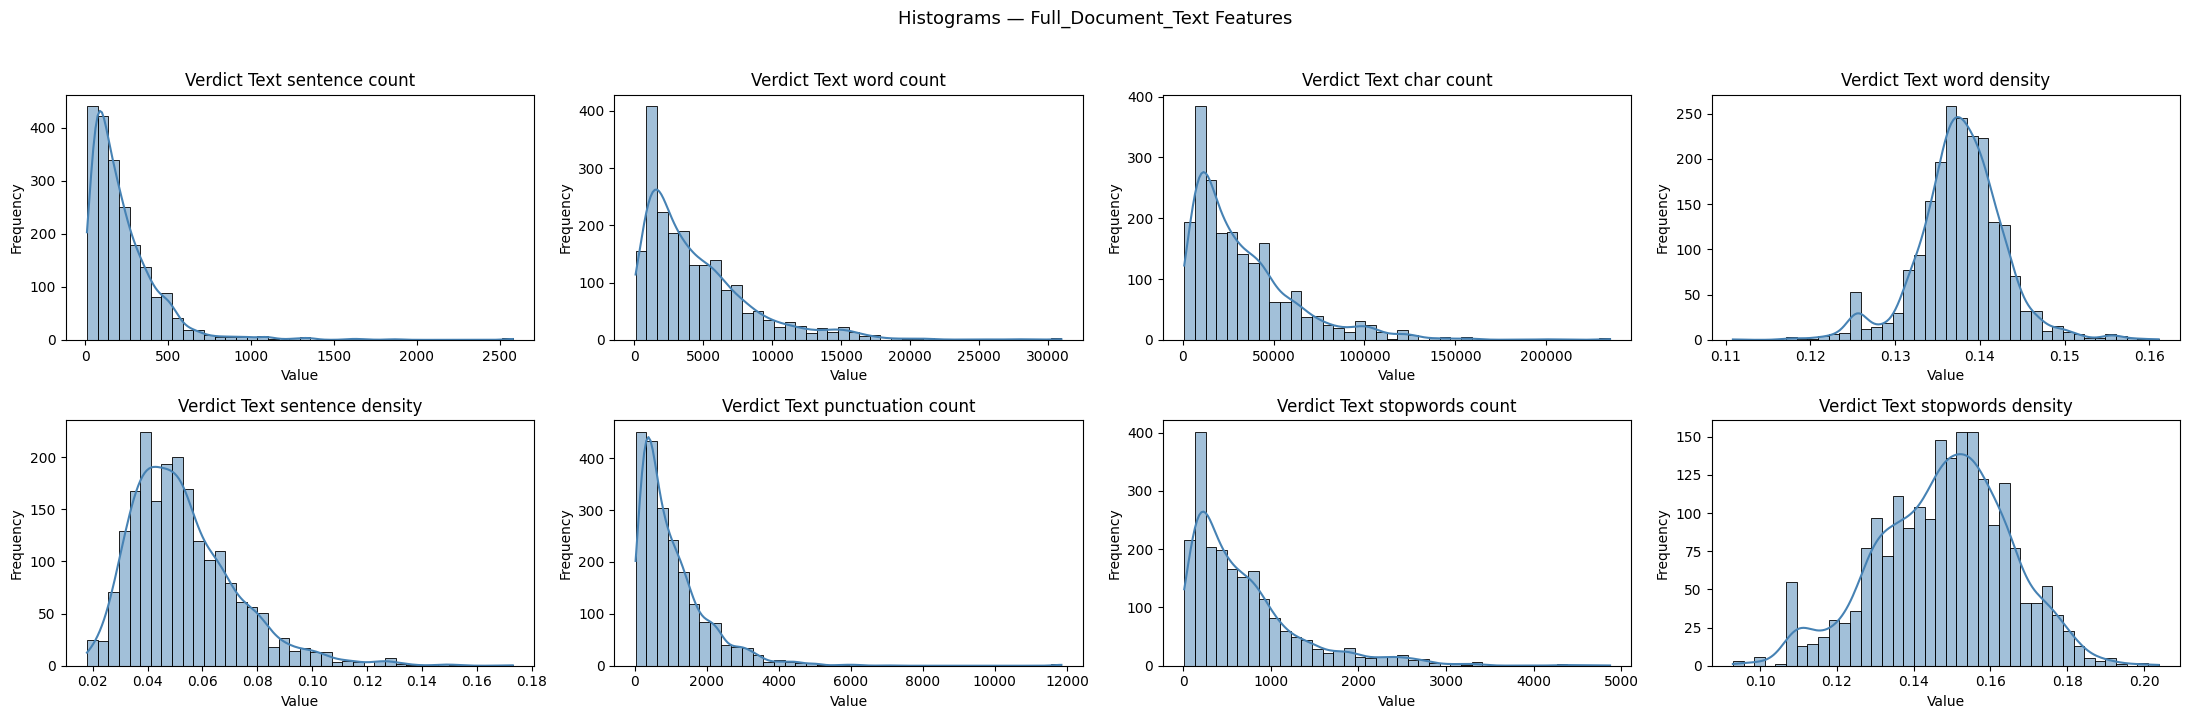

In [18]:
print('Histograms for Full_Document_Text features:')
plot_histograms(df_lower, feature_columns, num_rows=2, num_cols=4)

## 12. Correlation Heatmap

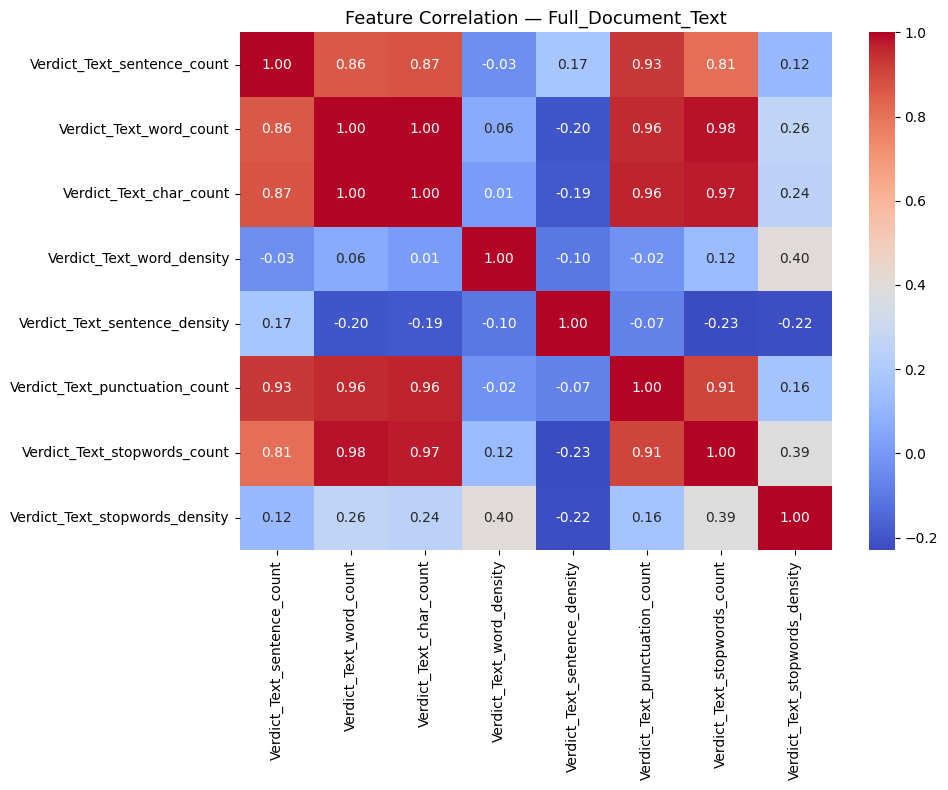

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_lower[feature_columns].corr()
short_labels = [c.replace('Full_Document_Text_', '') for c in feature_columns]
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    xticklabels=short_labels,
    yticklabels=short_labels,
    ax=ax
)
ax.set_title('Feature Correlation — Full_Document_Text', fontsize=13)
plt.tight_layout()
plt.show()

## 13. Armenian-Specific: Character Script Check

Verifies what fraction of each document is Armenian Unicode script (U+0531–U+058F).
Useful for detecting mixed-language or mis-encoded entries.

Armenian character ratio stats:


count    2073.000000
mean        0.997215
std         0.004418
min         0.938019
25%         0.996586
50%         0.998492
75%         0.999372
max         1.000000
Name: armenian_char_ratio, dtype: float64

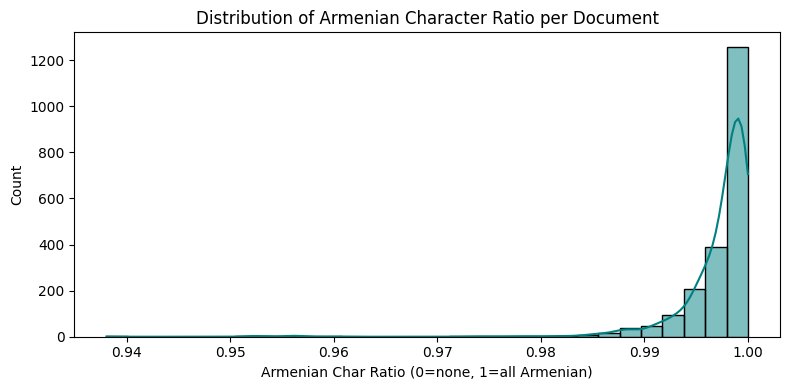


Documents with <50% Armenian characters: 0 (0.0%)


In [20]:
def armenian_char_ratio(text):
    """Fraction of alphabetic characters that are Armenian Unicode."""
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    alpha_chars = [c for c in text if c.isalpha()]
    if not alpha_chars:
        return 0.0
    armenian_chars = [c for c in alpha_chars if '\u0531' <= c <= '\u058f']
    return len(armenian_chars) / len(alpha_chars)

df_lower['armenian_char_ratio'] = df_lower[TEXT_COL].apply(armenian_char_ratio)

print('Armenian character ratio stats:')
display(df_lower['armenian_char_ratio'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_lower['armenian_char_ratio'], bins=30, ax=ax, color='teal', kde=True)
ax.set_title('Distribution of Armenian Character Ratio per Document')
ax.set_xlabel('Armenian Char Ratio (0=none, 1=all Armenian)')
plt.tight_layout()
plt.show()

low_armenian = df_lower[df_lower['armenian_char_ratio'] < 0.5]
print(f'\nDocuments with <50% Armenian characters: {len(low_armenian)} ({100*len(low_armenian)/len(df_lower):.1f}%)')
if len(low_armenian):
    display(low_armenian[[TEXT_COL, 'armenian_char_ratio']].head(5))

## 14. Top Tokens (Most Frequent Words after Stopword Removal)

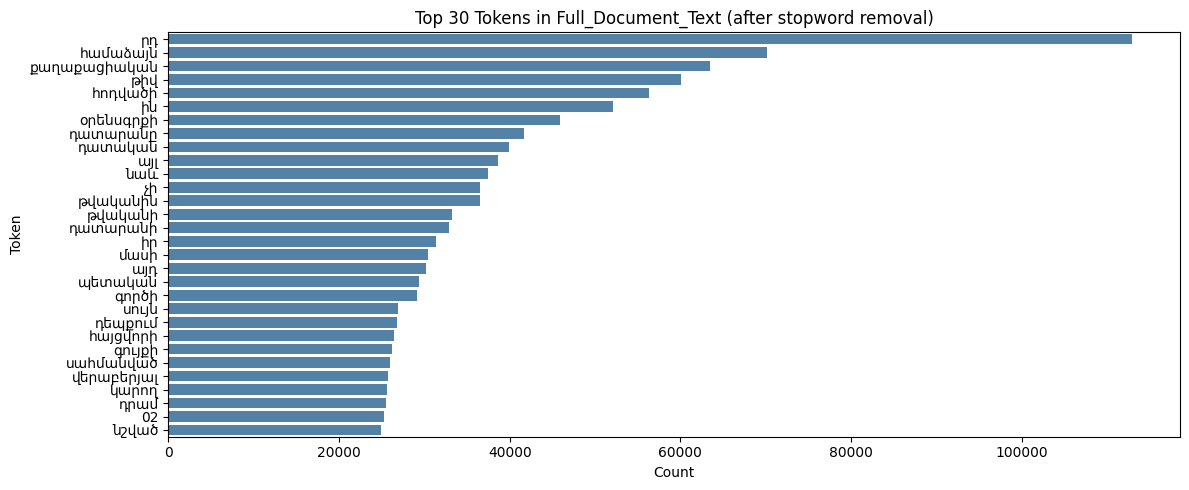

,token,count
0,րդ,112890
1,համաձայն,70191
2,քաղաքացիական,63489
3,թիվ,60055
4,հոդվածի,56280
5,ին,52151
6,օրենսգրքի,45857
7,դատարանը,41725
8,դատական,39861
9,այլ,38606


In [21]:
from collections import Counter

all_tokens = [tok for tokens in df_lower[f'Stop_{TEXT_COL}'] for tok in tokens if len(tok) > 1]
token_freq = Counter(all_tokens)
top_tokens = token_freq.most_common(30)

top_df = pd.DataFrame(top_tokens, columns=['token', 'count'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_df, x='count', y='token', ax=ax, color='steelblue')
ax.set_title('Top 30 Tokens in Full_Document_Text (after stopword removal)')
ax.set_xlabel('Count')
ax.set_ylabel('Token')
plt.tight_layout()
plt.show()

display(top_df)

---
## Notes on Seaborn for Armenian

| Concern | Status |
|---|---|
| **Axis labels / titles** (Armenian Unicode) | ✅ Works if your font supports it. Use `matplotlib.rcParams['font.family'] = 'DejaVu Sans'` (default) or set an Armenian-capable font. |
| **Tick labels from Armenian strings** | ✅ Renders correctly in modern matplotlib. |
| **Bar charts with Armenian token labels** | ✅ Top-tokens bar chart above uses `y='token'` — Armenian tokens display fine. |
| **Histograms / box plots** (numeric data) | ✅ No Armenian text involved — fully supported. |
| **Font rendering in saved PNGs** | ⚠️ If Armenian glyphs appear as boxes, install `fonts-noto` and set `rcParams['font.family'] = 'Noto Sans Armenian'`. |

```python
# Optional: force Armenian-capable font
import matplotlib
matplotlib.rcParams['font.family'] = 'Noto Sans Armenian'
```


In [22]:
df_final = df_lower[['Judge', 'Category', 'Case_Number']].copy()

df_final['Verdict_Text'] = (
    df_lower['Remove_emoji_Verdict_Text']
    .apply(tokenize)
    .apply(remove_stopwords_armenian)
    .apply(lambda tokens: ' '.join(tokens))
)

display(df_final.head(3))

,Judge,Category,Case_Number,Verdict_Text
0,Կարեն Մեժլումյան Սուրիկի,1.1 Գույքի նկատմամբ սեփականության իրավունքը ճա...,ԵԴ2/3094/02/24,պ ր զ ե ց ii նկարագրական մաս 1 գործի դատավարակ...
1,Կարեն Մեժլումյան Սուրիկի,4.9 Երեխայի բնակության վայրը որոշելու վերաբերյալ,ԵԴ2/8206/02/24,պ ր զ ե ց i նկարագրական մաս 1 գործի դատավարակա...
2,Կարեն Մեժլումյան Սուրիկի,2.1.2 Այդ թվում` գործարքի առոչնչության հետևանք...,ԵԴ2/9445/02/24,պ ր զ ե ց նկարագրական մաս 1 գործի դատավարական ...


In [23]:
df_final.to_csv("/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/src/data/Cleaned_Verdict_Text.csv", index=False)
print('Data saved successfully!')

Data saved successfully!
